In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mplPath
from matplotlib import pyplot
import geopandas as gpd
import pandas as pd
import cartopy.io.shapereader as shpreader
import geodatasets
import xarray as xr
import numpy as np
from geopandas import GeoSeries
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point , Polygon, MultiPolygon
from shapely.geometry.multipolygon import MultiPolygon
import shapely.wkt
import shapely.geometry
import shapely
from shapely.ops import nearest_points
from pathlib import Path
import rasterio
import rioxarray

d:\workstation\RESITING\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\595078\AppData\Local\Temp\ipykernel_6772\399816509.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  xr_elv = xr_elv.drop('spatial_ref', dim=None)
d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


                 lon        lat     elv                   geometry
0          97.252145  20.552498  1000.0   POINT (97.25215 20.5525)
1          97.252145  20.549998  1000.0     POINT (97.25215 20.55)
2          97.252145  20.547498  1000.0   POINT (97.25215 20.5475)
3          97.252145  20.544998  1000.0    POINT (97.25215 20.545)
4          97.252145  20.542498  1000.0   POINT (97.25215 20.5425)
...              ...        ...     ...                        ...
20405497  105.731728   5.529998  1000.0     POINT (105.73173 5.53)
20405498  105.731728   5.527498  1000.0   POINT (105.73173 5.5275)
20405499  105.731728   5.524998  1000.0    POINT (105.73173 5.525)
20405500  105.731728   5.522498  1000.0   POINT (105.73173 5.5225)
20405501  105.731728   5.520415  1000.0  POINT (105.73173 5.52041)

[20405502 rows x 4 columns]
<xarray.Dataset> Size: 82MB
Dimensions:  (lon: 3393, lat: 6014)
Coordinates:
  * lon      (lon) float64 27kB 97.25 97.25 97.26 97.26 ... 105.7 105.7 105.7
  * lat     

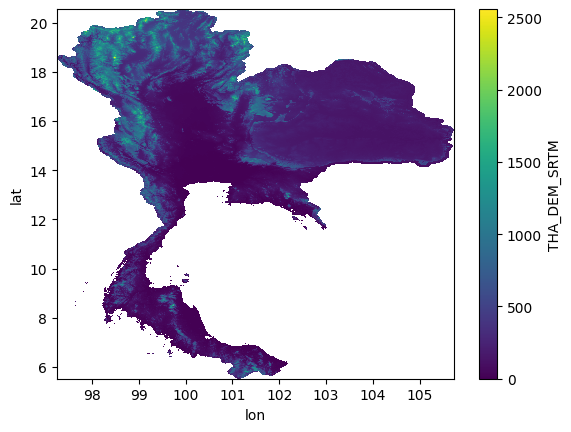

In [2]:
elv = rioxarray.open_rasterio('Data\\\THAILAND_SRTM\\\THAILAND\\tha_dem_srtm\\w001001.adf',masked=True)
xr_elv = elv.coarsen(x = 3, y= 3, boundary='pad').mean()

xr_elv = xr_elv.sel(band = 1)
xr_elv = xr_elv.drop_vars('band')
xr_elv = xr_elv.drop('spatial_ref', dim=None)
xr_elv = xr_elv.rename({'x':'lon'})
xr_elv = xr_elv.rename({'y':'lat'})
xr_elv = xr_elv.to_dataset(name='elv')
df_elv = xr_elv.to_dataframe()
df_elv.reset_index(inplace=True)
df_elv = gpd.GeoDataFrame(df_elv, geometry =gpd.points_from_xy(df_elv['lon'],df_elv['lat']))
df_elv.crs = {'init': 'epsg:4326'}
df_elv['elv'] = df_elv['elv'].fillna(1000)
print(df_elv)

xr_elv['elv'].plot()
print(xr_elv)

In [3]:
xr_landuse_suitability_index = xr.open_dataset('Output\\xr_SI_Landcover.nc')
df_slope_suitability_index = xr_landuse_suitability_index.to_dataframe()
df_slope_suitability_index.reset_index(inplace=True)
df_slope_suitability_index = gpd.GeoDataFrame(df_slope_suitability_index, geometry =gpd.points_from_xy(df_slope_suitability_index['lon'],df_slope_suitability_index['lat']))
df_slope_suitability_index.crs = {'init': 'epsg:4326'}
df_slope_suitability_index['SI_BGEC'] = 0
df_slope_suitability_index['SI_Biomass'] = 0
df_slope_suitability_index['SI_Solar'] = 0
df_slope_suitability_index['SI_Wind'] = 0
df_slope_suitability_index['SI_BGWW'] = 0
df_slope_suitability_index['SI_MSW'] = 0
df_slope_suitability_index['SI_IEW'] = 0
print(df_slope_suitability_index)

                lat         lon  lccs_class  SI_Solar  SI_Wind  SI_BGEC  \
0          5.615278   97.345833           0         0        0        0   
1          5.615278   97.348611           0         0        0        0   
2          5.615278   97.351389           0         0        0        0   
3          5.615278   97.354167           0         0        0        0   
4          5.615278   97.356944           0         0        0        0   
...             ...         ...         ...       ...      ...      ...   
15957805  20.462500  105.623611           0         0        0        0   
15957806  20.462500  105.626389           0         0        0        0   
15957807  20.462500  105.629167           0         0        0        0   
15957808  20.462500  105.631944           0         0        0        0   
15957809  20.462500  105.634722           0         0        0        0   

          SI_Biomass  SI_BGWW  SI_MSW  SI_IEW    ADM1_EN  A_BGEC  A_Biomass  \
0                  0

d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [4]:
df_slope_suitability_index = gpd.sjoin_nearest(df_slope_suitability_index,df_elv,how='left')

for i in df_slope_suitability_index.columns:
    if i not in (['lon_left','lat_left','geometry','elv','SI_BGEC','SI_Biomass','SI_Solar','SI_Wind','SI_BGWW','SI_MSW','SI_IEW']):
        df_slope_suitability_index = df_slope_suitability_index.drop(columns=i)

df_slope_suitability_index = df_slope_suitability_index.rename(columns= {'lon_left' : 'lon'})
df_slope_suitability_index = df_slope_suitability_index.rename(columns= {'lat_left' : 'lat'})
df_slope_suitability_index['elv']= df_slope_suitability_index['elv'].fillna(1000)

print(df_slope_suitability_index)

d:\workstation\RESITING\.env\Lib\site-packages\geopandas\array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


                lat         lon  SI_Solar  SI_Wind  SI_BGEC  SI_Biomass  \
0          5.615278   97.345833         0        0        0           0   
1          5.615278   97.348611         0        0        0           0   
2          5.615278   97.351389         0        0        0           0   
3          5.615278   97.354167         0        0        0           0   
4          5.615278   97.356944         0        0        0           0   
...             ...         ...       ...      ...      ...         ...   
15957805  20.462500  105.623611         0        0        0           0   
15957806  20.462500  105.626389         0        0        0           0   
15957807  20.462500  105.629167         0        0        0           0   
15957808  20.462500  105.631944         0        0        0           0   
15957809  20.462500  105.634722         0        0        0           0   

          SI_BGWW  SI_MSW  SI_IEW                   geometry     elv  
0               0       0   

In [5]:
## SI_BGEC ##
df_slope_suitability_index['SI_BGEC'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_BGEC'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_BGEC'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_BGEC'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

## SI_Biomass ##
df_slope_suitability_index['SI_Biomass'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_Biomass'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_Biomass'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_Biomass'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

## SI for Solar ##
df_slope_suitability_index['SI_Solar'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_Solar'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_Solar'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_Solar'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

## SI_Wind ##
df_slope_suitability_index['SI_Wind'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_Wind'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_Wind'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_Wind'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

## SI_BGWW ##
df_slope_suitability_index['SI_BGWW'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_BGWW'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_BGWW'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_BGWW'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

## SI_MSW ##
df_slope_suitability_index['SI_MSW'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_MSW'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_MSW'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_MSW'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

## SI_IEW ##
df_slope_suitability_index['SI_IEW'].loc[df_slope_suitability_index['elv'] > 200] = 0
df_slope_suitability_index['SI_IEW'].loc[(df_slope_suitability_index['elv'] > 150) & (df_slope_suitability_index['elv'] <= 200)] = 1
df_slope_suitability_index['SI_IEW'].loc[(df_slope_suitability_index['elv'] > 50) & (df_slope_suitability_index['elv'] <= 150)] = 2
df_slope_suitability_index['SI_IEW'].loc[df_slope_suitability_index['elv'] <= 50 ] = 3

print(df_slope_suitability_index)

C:\Users\595078\AppData\Local\Temp\ipykernel_6772\519199286.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_slope_suitability_index['SI_BGEC'].loc[df_slope_suitability_index['elv'] > 200] = 0
C:\Users\595078\AppData\Local\Temp\ipykern

                lat         lon  SI_Solar  SI_Wind  SI_BGEC  SI_Biomass  \
0          5.615278   97.345833         0        0        0           0   
1          5.615278   97.348611         0        0        0           0   
2          5.615278   97.351389         0        0        0           0   
3          5.615278   97.354167         0        0        0           0   
4          5.615278   97.356944         0        0        0           0   
...             ...         ...       ...      ...      ...         ...   
15957805  20.462500  105.623611         0        0        0           0   
15957806  20.462500  105.626389         0        0        0           0   
15957807  20.462500  105.629167         0        0        0           0   
15957808  20.462500  105.631944         0        0        0           0   
15957809  20.462500  105.634722         0        0        0           0   

          SI_BGWW  SI_MSW  SI_IEW                   geometry     elv  
0               0       0   

C:\Users\595078\AppData\Local\Temp\ipykernel_6772\519199286.py:38: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_slope_suitability_index['SI_IEW'].loc[df_slope_suitability_index['elv'] > 200] = 0
C:\Users\595078\AppData\Local\Temp\ipykern

In [6]:
df_slope_suitability_index.reset_index(inplace=True)

try: 
    df_slope_suitability_index = df_slope_suitability_index.drop(columns=['geometry'])
except:
    None

df_slope_suitability_index = df_slope_suitability_index.groupby(['lat', 'lon']).agg('mean')
df_slope_suitability_index.reset_index(inplace=True)
df_slope_suitability_index = df_slope_suitability_index.set_index(['lat', 'lon'])
try: 
    df_slope_suitability_index = df_slope_suitability_index.drop(columns=['index','elv'])
except:
    df_slope_suitability_index = df_slope_suitability_index.drop(columns=['elv'])

xr_slope_suitability_index = xr.Dataset.from_dataframe(df_slope_suitability_index)
xr_slope_suitability_index.to_netcdf(path='Output\\xr_SI_Elevation.nc')
print(xr_slope_suitability_index)


<xarray.Dataset> Size: 894MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    SI_Solar    (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Wind     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGEC     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_Biomass  (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_BGWW     (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_MSW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SI_IEW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


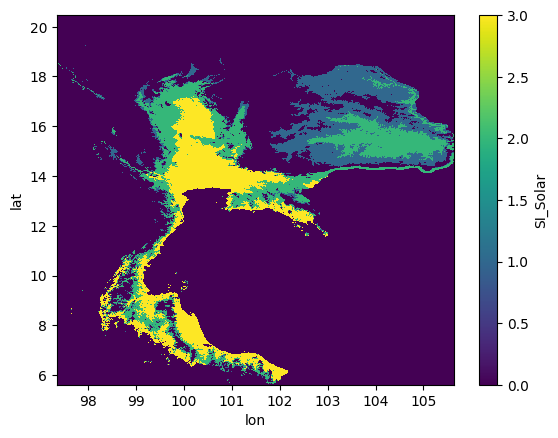

In [7]:
xr_slope_suitability_index['SI_Solar'].plot()

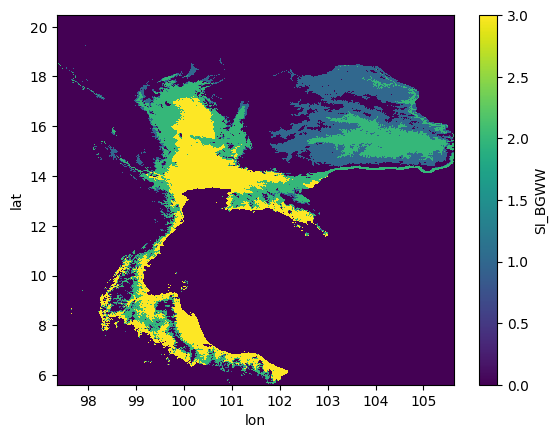

In [8]:
xr_slope_suitability_index['SI_BGWW'].plot()